In [1]:
"""
@
Auteurs:        Jeffrey Jason Boekstaaf, Tim Paulus van Croimvort en Haydar Eryörük
Studentnummers: 500460365, 500916516 en 500910901
Datum:          16-03-2026
Vak:            Beroepsproject 3.4
Opleiding:      Toegepaste Wiskunde & Data Science
School:         Hogeschool van Amsterdam
"""

import csv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import ensemble
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, RocCurveDisplay, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler 

# De data waarop getraind wordt.
data = pd.read_csv("data_train.csv", sep = ',')


In [2]:
# numerieke kolommen en categorische kolommen waarbij het referentie niveau gedropt wordt.
numcols = ['Call Failure','Subscription Length','Seconds of Use','Frequency of use','Frequency of SMS']
faccols = ['Age Group','Complaints']
droplevels = [1,0]

# columntransformer voor de datapreperatie fase.
dataprep_GB = ColumnTransformer([
    ('numeriek', StandardScaler(), numcols),
    ('categorisch', OneHotEncoder(drop = droplevels, sparse_output = False), faccols),
], remainder = 'drop', verbose_feature_names_out = False)

dataprep_GB.set_output(transform = 'pandas')
dataprep_GB


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeriek', ...), ('categorisch', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [3]:
# De churn wordt uit de traindata gelaten.
train = data.drop(columns = ['Churn'])
Y = data['Churn']

# Het splitsen van de data wordt hier gedaan.
X_train, X_test, Y_train, Y_test = train_test_split(train, Y, test_size = 0.2, random_state = 1987)

# Het model wordt meegegeven aan de pipeline om gebruikt te worden in de evaluation en deployment.
model_GB = Pipeline([('preprocessing', dataprep_GB),
                    ('modelGB', ensemble.GradientBoostingClassifier(
                    min_samples_split = 5,
                    loss = "log_loss",
                    n_estimators = 2000,
                    max_depth = 10,
                    learning_rate = 10))])
model_GB.fit(X_train, Y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('modelGB', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeriek', ...), ('categorisch', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

In [4]:
# We slaan de pipeline op als een pickle bestand.
with open('pipelineGB.pkl', 'wb') as file:
    pickle.dump(model_GB, file)


In [5]:
# Gridsearch voor gradient boosting met willekeurig gekozen waarden.
gridsearch_GB = GridSearchCV(
    estimator = ensemble.GradientBoostingClassifier(min_samples_split = 5, loss = "log_loss"), 
    param_grid = [{
        "n_estimators" : [2000, 3000, 4000, 5000, 6000],
        "max_depth": [10, 11, 12, 13, 14], 
        "learning_rate": [0.01, 0.1, 1, 10]}],
    scoring = 'accuracy',
    verbose = 2)

gridsearch_GB.fit(X_train, Y_train)

# Na de gridsearch met deze parameters laten zien welke combinatie het beste is.
gridsearch_GB.best_estimator_


Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END learning_rate=0.01, max_depth=10, n_estimators=2000; total time=  29.9s
[CV] END learning_rate=0.01, max_depth=10, n_estimators=2000; total time=  34.1s
[CV] END learning_rate=0.01, max_depth=10, n_estimators=2000; total time=  34.3s
[CV] END learning_rate=0.01, max_depth=10, n_estimators=2000; total time=  30.4s
[CV] END learning_rate=0.01, max_depth=10, n_estimators=2000; total time=  24.8s
[CV] END learning_rate=0.01, max_depth=10, n_estimators=3000; total time=  57.8s
[CV] END learning_rate=0.01, max_depth=10, n_estimators=3000; total time= 1.2min
[CV] END learning_rate=0.01, max_depth=10, n_estimators=3000; total time= 1.3min
[CV] END learning_rate=0.01, max_depth=10, n_estimators=3000; total time= 1.3min
[CV] END learning_rate=0.01, max_depth=10, n_estimators=3000; total time= 1.3min
[CV] END learning_rate=0.01, max_depth=10, n_estimators=4000; total time=  52.2s
[CV] END learning_rate=0.01, max_depth=10, n_e

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",2000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",10
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``

In [10]:
# Uit de gridsearchs zijn deze parameters als de beste samenstelling gekomen en daarom dienen zij hier aangepast te worden.
model_GB.learning_rate = 0.1
model_GB.max_depth = 10
model_GB.n_estimators = 2000


In [11]:
# Hier wordt het voorspellen op de validatiedata gedaan.
predicted = model_GB.predict(X_test)


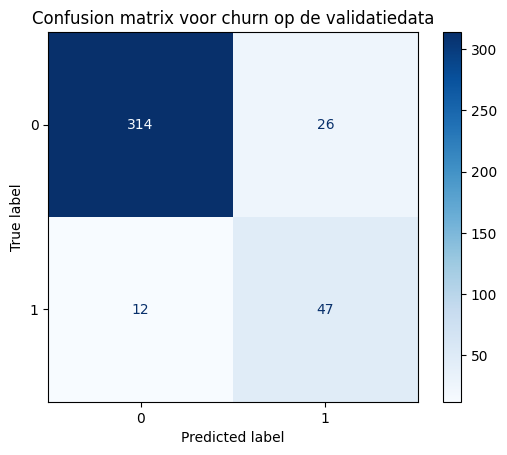

In [12]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(Y_test, predicted, cmap = 'Blues')
plt.title("Confusion matrix voor churn op de validatiedata")
plt.show()


Hier valt de confusion matrix af te lezen op de validatiedata. Er is te zien dat zowel de daadwerkelijke waarden van 0 en 1 met respectievelijk voorspelde waarden 0 en 1 de twee grootste groepen zijn. De twee kleinste groepen zijn de foute groepen.

In [13]:
# Hier worden de accuracy, f1, precision en recall scores berekend en gegeven.
acc = round(accuracy_score(Y_test, predicted), 2)
rec = round(recall_score(Y_test, predicted), 2)
pre = round(precision_score(Y_test, predicted), 2)
fsco = round(f1_score(Y_test, predicted), 2)
table = {"Name": ["Accuracy", "Recall", "Precision", "F1-score"],
        "Value": [acc, rec, pre, fsco]}
df = pd.DataFrame(table)
df


,Name,Value
0,Accuracy,0.90
1,Recall,0.80
2,Precision,0.64
3,F1-score,0.71


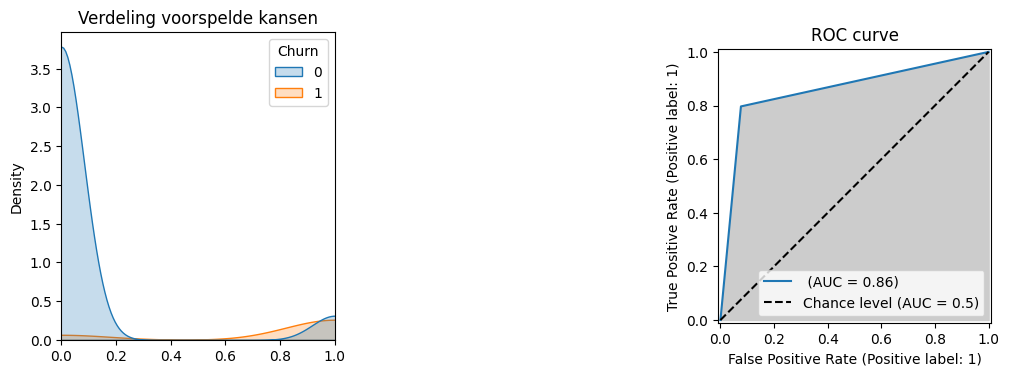

In [15]:
# Verdeling van de voorspelde kansen.
plt.figure(figsize = (12, 4))
plt.subplot(1, 3, 1)
sns.kdeplot(data = pd.DataFrame(Y_test), x = predicted[:], hue = 'Churn', fill = True)
plt.xlim(0, 1)
plt.title('Verdeling voorspelde kansen')

# Zet een classification report om in een rij van een dataframe
def make_row(cr):
    return {
        'Accuracy':  cr['accuracy'],
        'Recall':    cr['1']['recall'],
        'Precision': cr['1']['precision'],
        'F1 Score':  cr['1']['f1-score']
    }

# ROC-curve
ax = plt.subplot(1, 3, 3)
roc = RocCurveDisplay.from_predictions(
    Y_test, 
    predicted[:], 
    name = '', 
    plot_chance_level = True,
    ax = ax)
plt.fill_between(roc.fpr, roc.tpr, color = '0.8')
plt.title('ROC curve')
plt.show()
